In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_2020.nc
/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_2000.nc
/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_2018.nc
/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_2011.nc
/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_2009.nc
/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_1999.nc
/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_1991.nc
/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_2001.nc
/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_2023.nc
/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_2012.nc
/kaggle/in

In [2]:
!pip install zarr gcsfs fsspec xarray --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 7.0 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 72.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2025.3.0 which is incompatible.


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:24

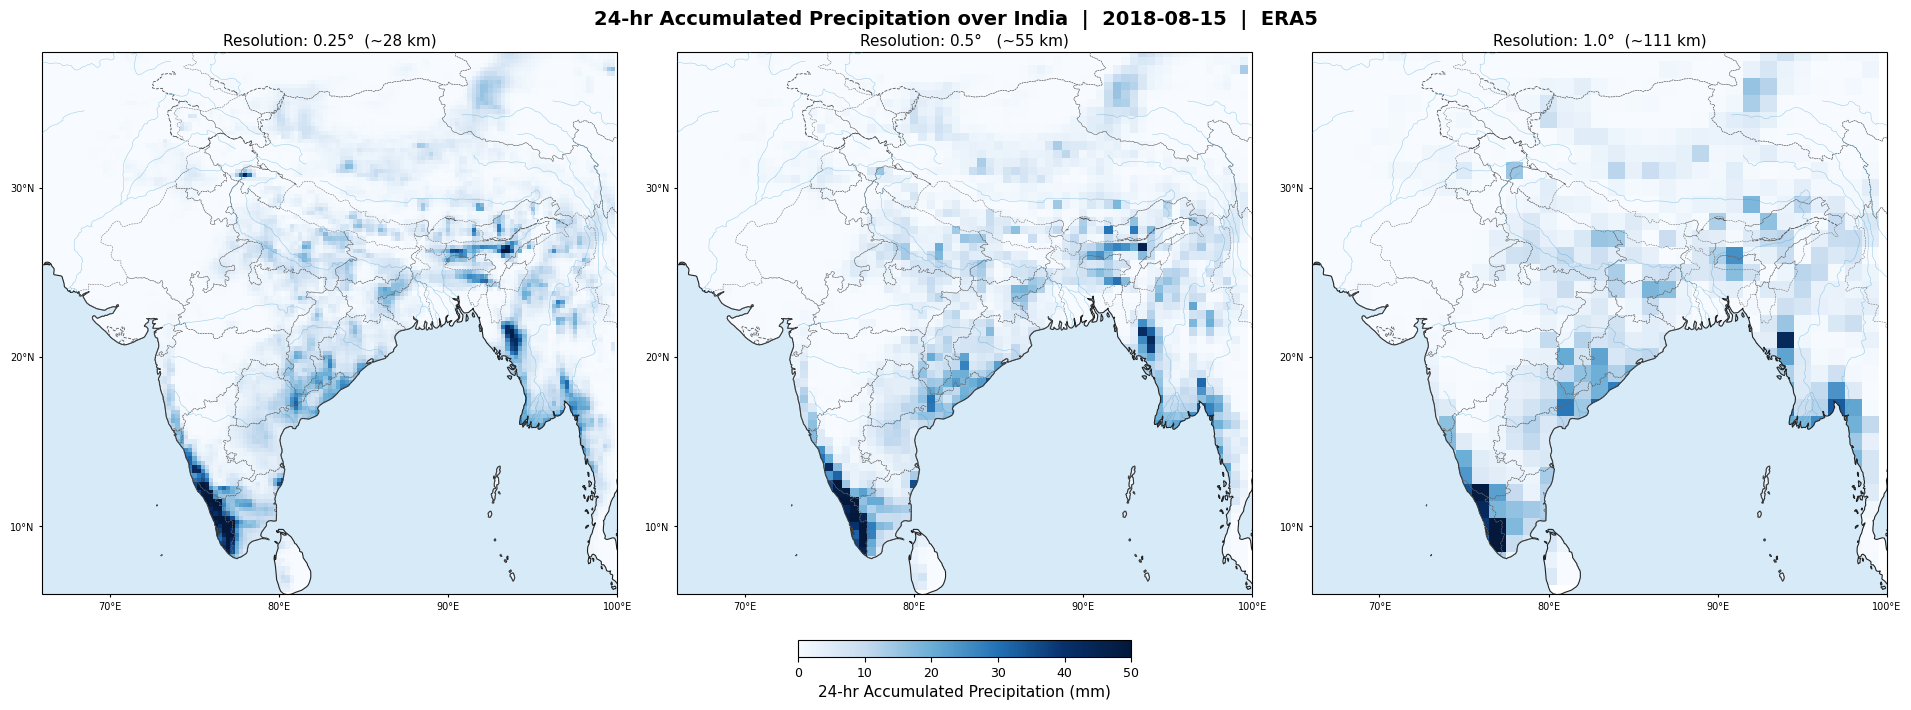

Done → india_precip_2018_3res.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# ── Load dataset ──────────────────────────────────────────────────────────────
path = "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"
ds = xr.open_zarr(path, consolidated=True, storage_options={"token": "anon"})

# ── Date: peak monsoon with widespread India rainfall (pre-2019) ──────────────
time_sel = "2018-08-15T00:00:00"
ds_t = ds.sel(time=time_sel)

# ── Indian region bounds (Kashmir fully included) ─────────────────────────────
lat_min, lat_max =  6.0, 38.0
lon_min, lon_max = 66.0, 100.0

# ── Resolution grids ──────────────────────────────────────────────────────────
lat_025 = np.arange(lat_max, lat_min, -0.25)
lon_025 = np.arange(lon_min, lon_max,  0.25)

lat_05  = np.arange(lat_max, lat_min, -0.5)
lon_05  = np.arange(lon_min, lon_max,  0.5)

lat_1   = np.arange(lat_max, lat_min, -1.0)
lon_1   = np.arange(lon_min, lon_max,  1.0)

# ── Extract precipitation (mm) ────────────────────────────────────────────────
def get_tp(lats, lons):
    return ds_t['total_precipitation_12hr'].sel(
        latitude=lats, longitude=lons, method='nearest'
    ).values * 1000.0

tp_025 = get_tp(lat_025, lon_025)
tp_05  = get_tp(lat_05,  lon_05)
tp_1   = get_tp(lat_1,   lon_1)

# ── Bluish colormap ───────────────────────────────────────────────────────────
colors_tp = ['#f7fbff', '#c6dbef', '#6baed6', '#2171b5', '#08306b', '#03183a']
cmap_tp   = mcolors.LinearSegmentedColormap.from_list('tp_blue', colors_tp, N=256)
vmin, vmax = 0, 50  # mm per 12 hr

datasets = [
    (tp_025, lat_025, lon_025, '0.25°  (~28 km)'),
    (tp_05,  lat_05,  lon_05,  '0.5°   (~55 km)'),
    (tp_1,   lat_1,   lon_1,   '1.0°  (~111 km)'),
]

# ── Natural Earth admin-1 shapefile (shows Kashmir in India) ──────────────────
import cartopy.io.shapereader as shpreader
from matplotlib.patches import PathPatch
from matplotlib.path import Path

# ── Plot ──────────────────────────────────────────────────────────────────────
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 3,
    figsize=(19, 7),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

fig.suptitle(
    f'24-hr Accumulated Precipitation over India  |  {time_sel[:10]}  |  ERA5',
    fontsize=14, fontweight='bold'
)

for ax, (vals, lats, lons, res_label) in zip(axes, datasets):
    lons2d, lats2d = np.meshgrid(lons, lats)

    ax.pcolormesh(
        lons2d, lats2d, vals,
        cmap=cmap_tp, vmin=vmin, vmax=vmax,
        transform=proj, shading='auto'
    )

    # ── Base features ─────────────────────────────────────────────────────────
    ax.add_feature(cfeature.OCEAN,     facecolor='#d6eaf8', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,  edgecolor='#222222', zorder=3)
    ax.add_feature(cfeature.STATES,    linewidth=0.35, edgecolor='#666666',
                   linestyle='--', zorder=3)

    # ── Use Natural Earth 10m admin-0 boundaries (India includes Kashmir) ─────
    # Download 10m cultural boundaries
    ne_countries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_countries',
        scale='10m',
        facecolor='none',
        edgecolor='#111111'
    )
    ne_disputed = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_disputed_areas',
        scale='10m',
        facecolor='none',
        edgecolor='#555555'
    )
    # ax.add_feature(ne_countries,  linewidth=0.9, zorder=4)
    ax.add_feature(ne_disputed,   linewidth=0.6, linestyle='--', zorder=10)

    # ── Rivers for geographic context ─────────────────────────────────────────
    ax.add_feature(cfeature.RIVERS, linewidth=0.4, edgecolor='#3399cc', alpha=0.45, zorder=3)

    # ── Extent ────────────────────────────────────────────────────────────────
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    # ── No gridlines ──────────────────────────────────────────────────────────

    # ── Axis labels only (no grid) ────────────────────────────────────────────
    ax.set_xticks(np.arange(70, 101, 10), crs=proj)
    ax.set_yticks(np.arange(10, 38, 10),  crs=proj)
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=7, length=2)

    ax.set_title(f'Resolution: {res_label}', fontsize=11, pad=5)

# ── Shared colorbar ───────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap_tp, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal',
                    fraction=0.03, pad=0.05, shrink=0.75)
cbar.set_label('24-hr Accumulated Precipitation (mm)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.savefig('india_precip_2018_3res.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Done → india_precip_2018_3res.png")

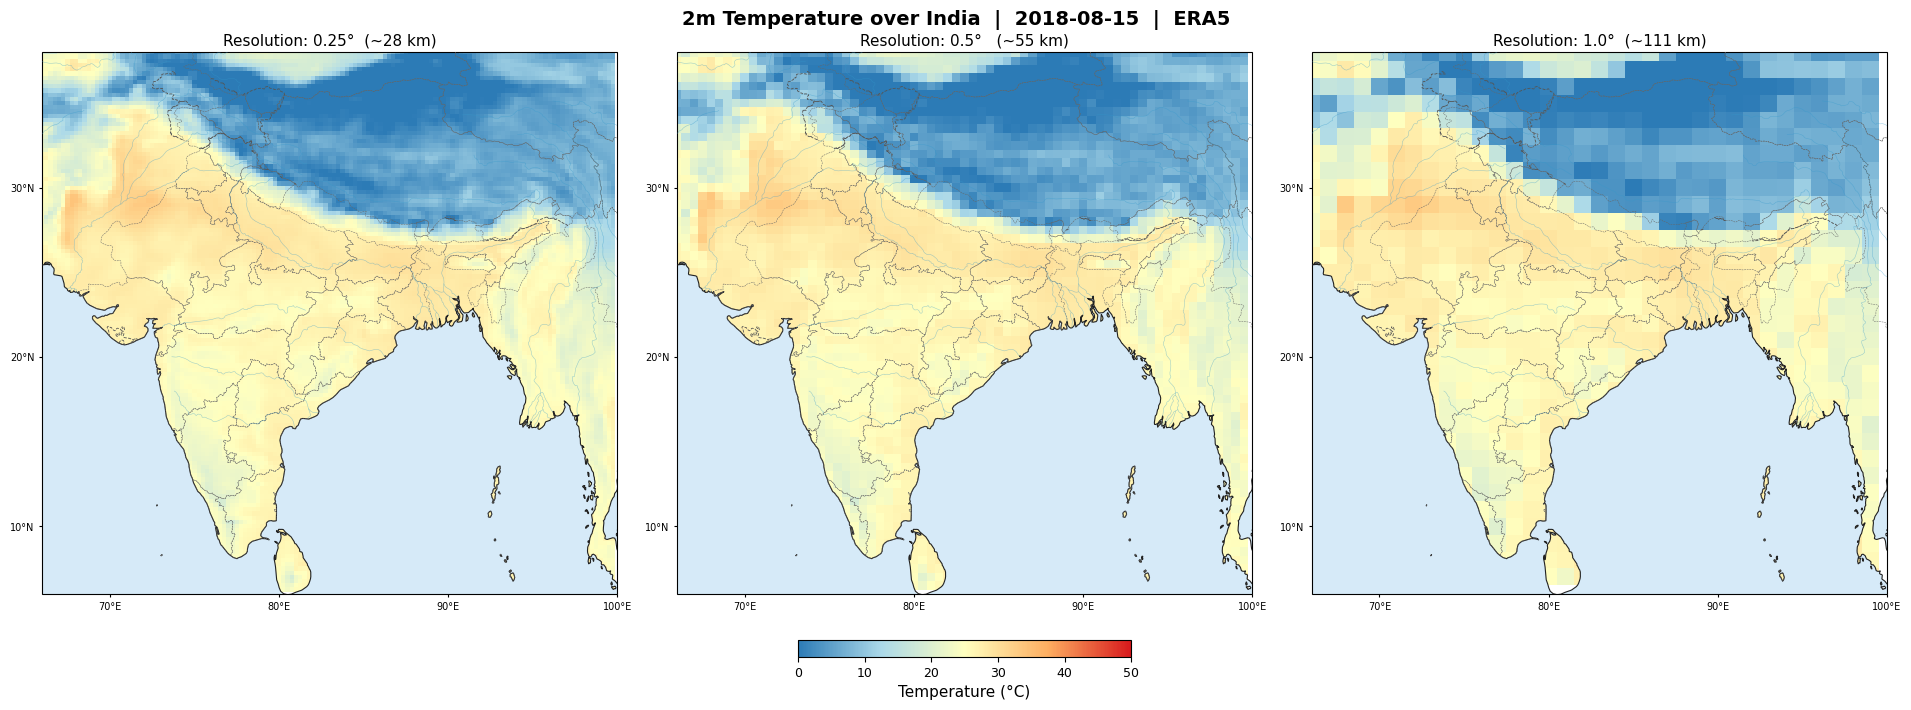

In [4]:
# ── Extract temperature (°C) ─────────────────────────────────────
def get_temp(lats, lons):
    return ds_t['2m_temperature'].sel(
        latitude=lats, longitude=lons, method='nearest'
    ).values - 273.15  # Kelvin → Celsius

t_025 = get_temp(lat_025, lon_025)
t_05  = get_temp(lat_05,  lon_05)
t_1   = get_temp(lat_1,   lon_1)

# ── Temperature Colormap (Cold → Warm → Hot) ─────────────────────
colors_temp = [
    "#2c7bb6",   # cold blue
    "#abd9e9",
    "#ffffbf",   # neutral (yellow)
    "#fdae61",
    "#d7191c"    # hot red
]
cmap_temp = mcolors.LinearSegmentedColormap.from_list("temp_map", colors_temp, N=256)

vmin, vmax = 0, 50  # India realistic range

datasets = [
    (t_025, lat_025, lon_025, '0.25°  (~28 km)'),
    (t_05,  lat_05,  lon_05,  '0.5°   (~55 km)'),
    (t_1,   lat_1,   lon_1,   '1.0°  (~111 km)'),
]

# ── Plot (SAME STRUCTURE) ────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(19, 7),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

fig.suptitle(
    f'2m Temperature over India  |  {time_sel[:10]}  |  ERA5',
    fontsize=14, fontweight='bold'
)

for ax, (vals, lats, lons, res_label) in zip(axes, datasets):
    lons2d, lats2d = np.meshgrid(lons, lats)

    ax.pcolormesh(
        lons2d, lats2d, vals,
        cmap=cmap_temp, vmin=vmin, vmax=vmax,
        transform=proj, shading='auto'
    )

    # SAME FEATURES (DON'T CHANGE)
    ax.add_feature(cfeature.OCEAN, facecolor='#d6eaf8', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#222222', zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor='#666666',
                   linestyle='--', zorder=3)

    ax.add_feature(ne_disputed, linewidth=0.6, linestyle='--', zorder=10)

    ax.add_feature(cfeature.RIVERS, linewidth=0.4,
                   edgecolor='#3399cc', alpha=0.45, zorder=3)

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    ax.set_xticks(np.arange(70, 101, 10), crs=proj)
    ax.set_yticks(np.arange(10, 38, 10), crs=proj)

    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=7, length=2)

    ax.set_title(f'Resolution: {res_label}', fontsize=11, pad=5)

# ── Colorbar ─────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap_temp, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar = fig.colorbar(
    sm, ax=axes, orientation='horizontal',
    fraction=0.03, pad=0.05, shrink=0.75
)

cbar.set_label('Temperature (°C)', fontsize=11)
cbar.ax.tick_params(labelsize=9)
plt.savefig(
    "india_temperature_2018_3res.png",
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

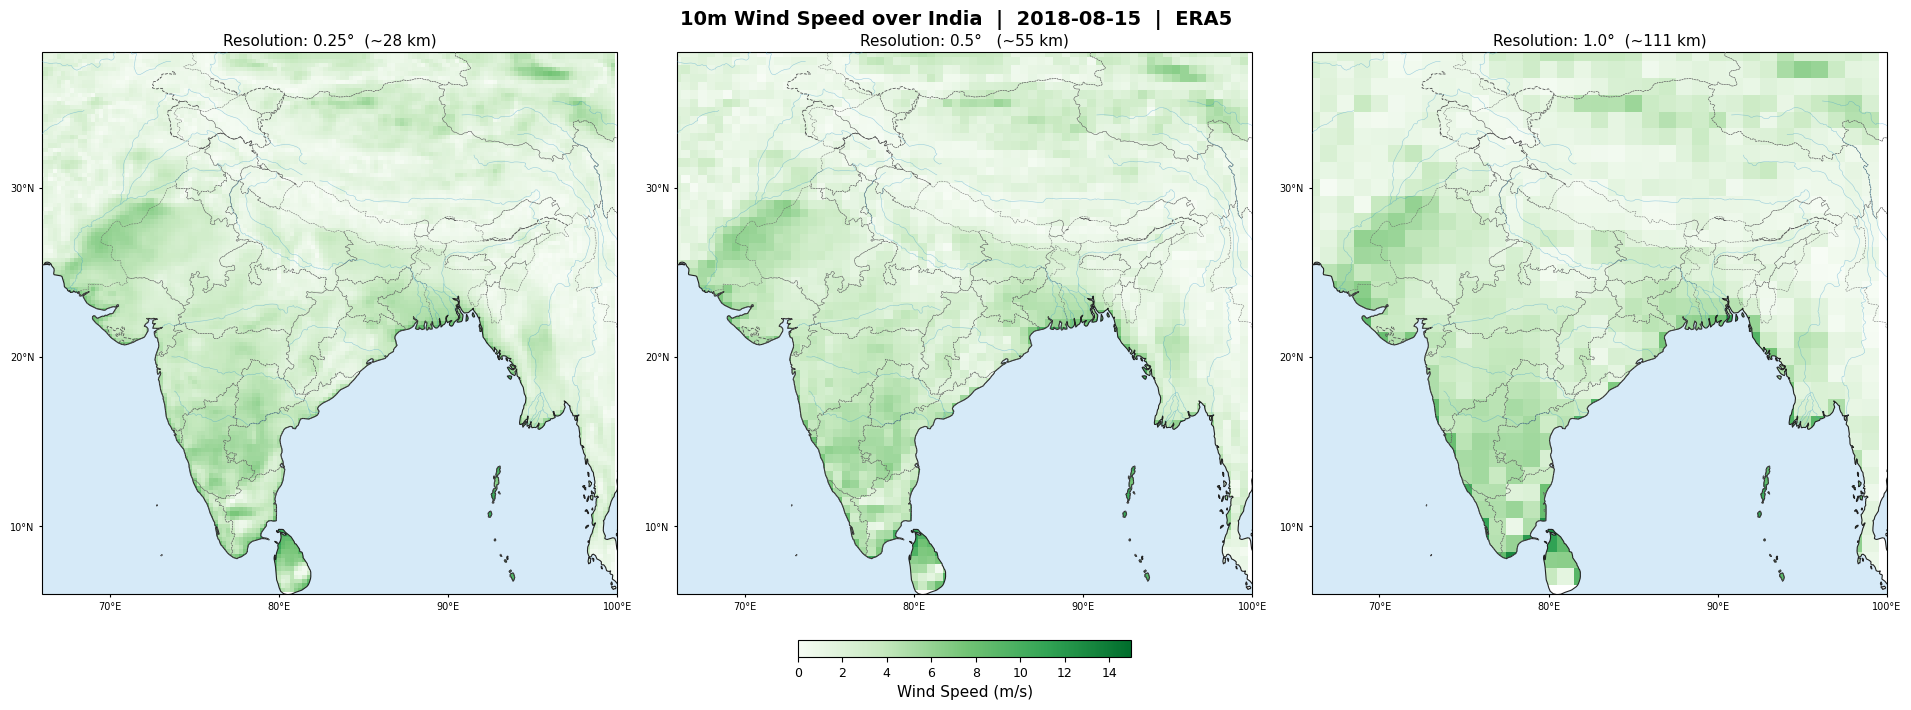

Done → india_wind_2018_3res.png


In [5]:
# ── Compute wind speed (m/s) ─────────────────────────────────────
def get_wind(lats, lons):
    u = ds_t['10m_u_component_of_wind'].sel(
        latitude=lats, longitude=lons, method='nearest'
    ).values
    
    v = ds_t['10m_v_component_of_wind'].sel(
        latitude=lats, longitude=lons, method='nearest'
    ).values
    
    return np.sqrt(u**2 + v**2)

w_025 = get_wind(lat_025, lon_025)
w_05  = get_wind(lat_05,  lon_05)
w_1   = get_wind(lat_1,   lon_1)

# ── Wind Colormap (flow intensity) ───────────────────────────────
colors_wind = [
    "#f7fcf5",  # very light (low wind)
    "#c7e9c0",
    "#74c476",
    "#31a354",
    "#006d2c"   # dark green (high wind)
]
cmap_wind = mcolors.LinearSegmentedColormap.from_list("wind_map", colors_wind, N=256)

vmin, vmax = 0, 15  # m/s typical range

datasets = [
    (w_025, lat_025, lon_025, '0.25°  (~28 km)'),
    (w_05,  lat_05,  lon_05,  '0.5°   (~55 km)'),
    (w_1,   lat_1,   lon_1,   '1.0°  (~111 km)'),
]

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(19, 7),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

fig.suptitle(
    f'10m Wind Speed over India  |  {time_sel[:10]}  |  ERA5',
    fontsize=14,
    fontweight='bold'
)

for ax, (vals, lats, lons, res_label) in zip(axes, datasets):

    lons2d, lats2d = np.meshgrid(lons, lats)

    ax.pcolormesh(
        lons2d, lats2d, vals,
        cmap=cmap_wind,
        vmin=vmin, vmax=vmax,
        transform=proj,
        shading='auto'
    )

    # SAME FEATURES
    ax.add_feature(cfeature.OCEAN, facecolor='#d6eaf8', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#222222', zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor='#666666',
                   linestyle='--', zorder=3)

    ax.add_feature(ne_disputed, linewidth=0.6, linestyle='--', zorder=10)

    ax.add_feature(cfeature.RIVERS, linewidth=0.4,
                   edgecolor='#3399cc', alpha=0.45, zorder=3)

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    ax.set_xticks(np.arange(70, 101, 10), crs=proj)
    ax.set_yticks(np.arange(10, 38, 10), crs=proj)

    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=7, length=2)

    ax.set_title(f'Resolution: {res_label}', fontsize=11, pad=5)

# ── Colorbar ─────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=cmap_wind,
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm.set_array([])

cbar = fig.colorbar(
    sm, ax=axes,
    orientation='horizontal',
    fraction=0.03,
    pad=0.05,
    shrink=0.75
)

cbar.set_label('Wind Speed (m/s)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# ── Save ─────────────────────────────────────────────────────────
plt.savefig(
    "india_wind_2018_3res.png",
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Done → india_wind_2018_3res.png")

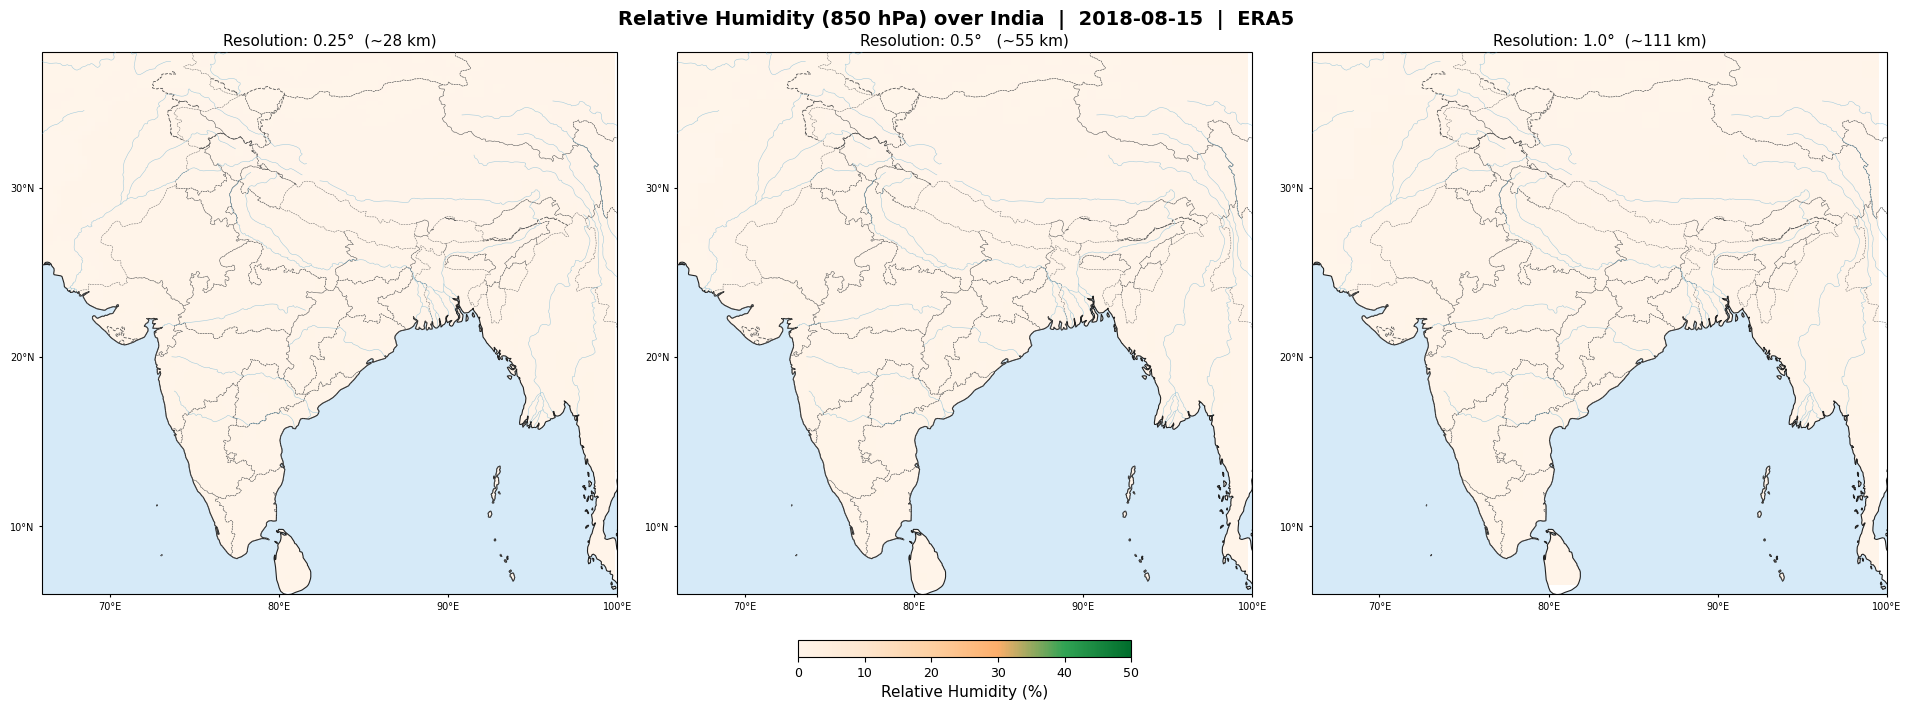

Done → india_humidity_2018_3res.png


In [29]:
# ── Extract relative humidity (%) ────────────────────────────────
def get_rh(lats, lons):
    return ds_t['relative_humidity'].sel(
        level=850,   # common pressure level (can change if needed)
        latitude=lats,
        longitude=lons,
        method='nearest'
    ).values

rh_025 = get_rh(lat_025, lon_025)
rh_05  = get_rh(lat_05,  lon_05)
rh_1   = get_rh(lat_1,   lon_1)

# ── Humidity Colormap (dry → moist) ──────────────────────────────
colors_rh = [
    "#fff5eb",  # very dry (light)
    "#fee6ce",
    "#fdd0a2",
    "#fdae6b",
    "#31a354",  # moist
    "#006d2c"   # very moist
]
cmap_rh = mcolors.LinearSegmentedColormap.from_list("rh_map", colors_rh, N=256)

vmin, vmax = 0, 50  # percentage

datasets = [
    (rh_025, lat_025, lon_025, '0.25°  (~28 km)'),
    (rh_05,  lat_05,  lon_05,  '0.5°   (~55 km)'),
    (rh_1,   lat_1,   lon_1,   '1.0°  (~111 km)'),
]

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(19, 7),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

fig.suptitle(
    f'Relative Humidity (850 hPa) over India  |  {time_sel[:10]}  |  ERA5',
    fontsize=14,
    fontweight='bold'
)

for ax, (vals, lats, lons, res_label) in zip(axes, datasets):

    lons2d, lats2d = np.meshgrid(lons, lats)

    ax.pcolormesh(
        lons2d, lats2d, vals,
        cmap=cmap_rh,
        vmin=vmin, vmax=vmax,
        transform=proj,
        shading='auto'
    )

    # SAME FEATURES
    ax.add_feature(cfeature.OCEAN, facecolor='#d6eaf8', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#222222', zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor='#666666',
                   linestyle='--', zorder=3)

    ax.add_feature(ne_disputed, linewidth=0.6, linestyle='--', zorder=10)

    ax.add_feature(cfeature.RIVERS, linewidth=0.4,
                   edgecolor='#3399cc', alpha=0.45, zorder=3)

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    ax.set_xticks(np.arange(70, 101, 10), crs=proj)
    ax.set_yticks(np.arange(10, 38, 10), crs=proj)

    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=7, length=2)

    ax.set_title(f'Resolution: {res_label}', fontsize=11, pad=5)

# ── Colorbar ─────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=cmap_rh,
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm.set_array([])

cbar = fig.colorbar(
    sm, ax=axes,
    orientation='horizontal',
    fraction=0.03,
    pad=0.05,
    shrink=0.75
)

cbar.set_label('Relative Humidity (%)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# ── Save ─────────────────────────────────────────────────────────
plt.savefig(
    "india_humidity_2018_3res.png",
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Done → india_humidity_2018_3res.png")

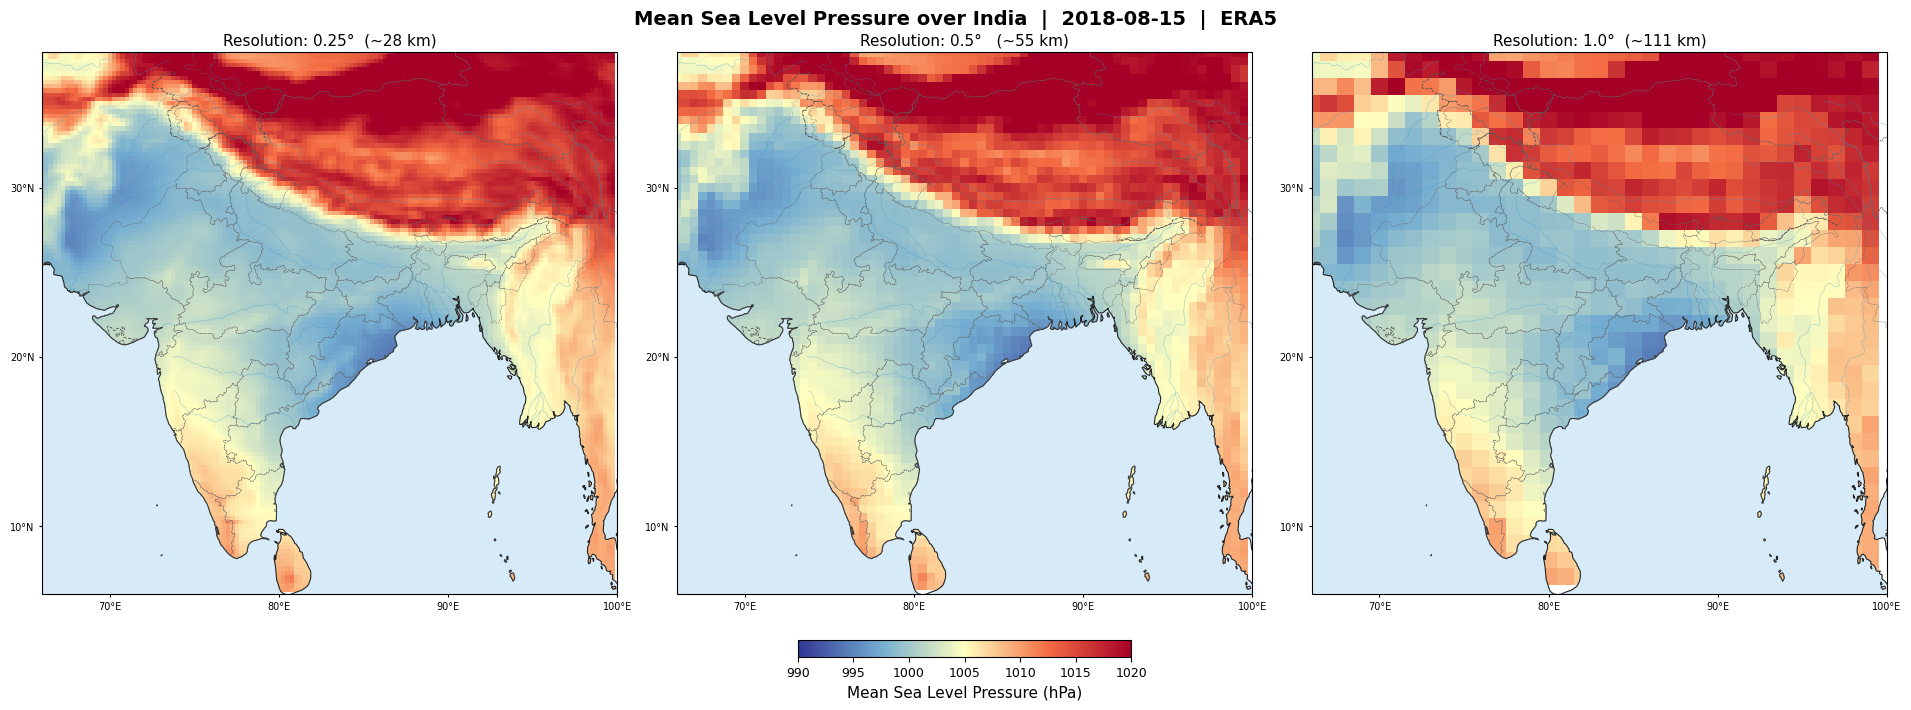

Done → india_mslp_2018_3res.png


In [7]:
# ── Extract MSLP (hPa) ───────────────────────────────────────────
def get_mslp(lats, lons):
    return ds_t['mean_sea_level_pressure'].sel(
        latitude=lats,
        longitude=lons,
        method='nearest'
    ).values / 100.0   # Pa → hPa

p_025 = get_mslp(lat_025, lon_025)
p_05  = get_mslp(lat_05,  lon_05)
p_1   = get_mslp(lat_1,   lon_1)

# ── Pressure Colormap (low → high) ───────────────────────────────
colors_mslp = [
    "#313695",  # low pressure (blue)
    "#74add1",
    "#ffffbf",  # neutral
    "#f46d43",
    "#a50026"   # high pressure (red)
]
cmap_mslp = mcolors.LinearSegmentedColormap.from_list("mslp_map", colors_mslp, N=256)

vmin, vmax = 990, 1020  # typical India range

datasets = [
    (p_025, lat_025, lon_025, '0.25°  (~28 km)'),
    (p_05,  lat_05,  lon_05,  '0.5°   (~55 km)'),
    (p_1,   lat_1,   lon_1,   '1.0°  (~111 km)'),
]

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 3,
    figsize=(19, 7),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

fig.suptitle(
    f'Mean Sea Level Pressure over India  |  {time_sel[:10]}  |  ERA5',
    fontsize=14,
    fontweight='bold'
)

for ax, (vals, lats, lons, res_label) in zip(axes, datasets):

    lons2d, lats2d = np.meshgrid(lons, lats)

    ax.pcolormesh(
        lons2d, lats2d, vals,
        cmap=cmap_mslp,
        vmin=vmin, vmax=vmax,
        transform=proj,
        shading='auto'
    )

    # SAME FEATURES
    ax.add_feature(cfeature.OCEAN, facecolor='#d6eaf8', zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#222222', zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor='#666666',
                   linestyle='--', zorder=3)

    ax.add_feature(ne_disputed, linewidth=0.6, linestyle='--', zorder=10)

    ax.add_feature(cfeature.RIVERS, linewidth=0.4,
                   edgecolor='#3399cc', alpha=0.45, zorder=3)

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    ax.set_xticks(np.arange(70, 101, 10), crs=proj)
    ax.set_yticks(np.arange(10, 38, 10), crs=proj)

    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=7, length=2)

    ax.set_title(f'Resolution: {res_label}', fontsize=11, pad=5)

# ── Colorbar ─────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=cmap_mslp,
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm.set_array([])

cbar = fig.colorbar(
    sm, ax=axes,
    orientation='horizontal',
    fraction=0.03,
    pad=0.05,
    shrink=0.75
)

cbar.set_label('Mean Sea Level Pressure (hPa)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# ── Save ─────────────────────────────────────────────────────────
plt.savefig(
    "india_mslp_2018_3res.png",
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("Done → india_mslp_2018_3res.png")

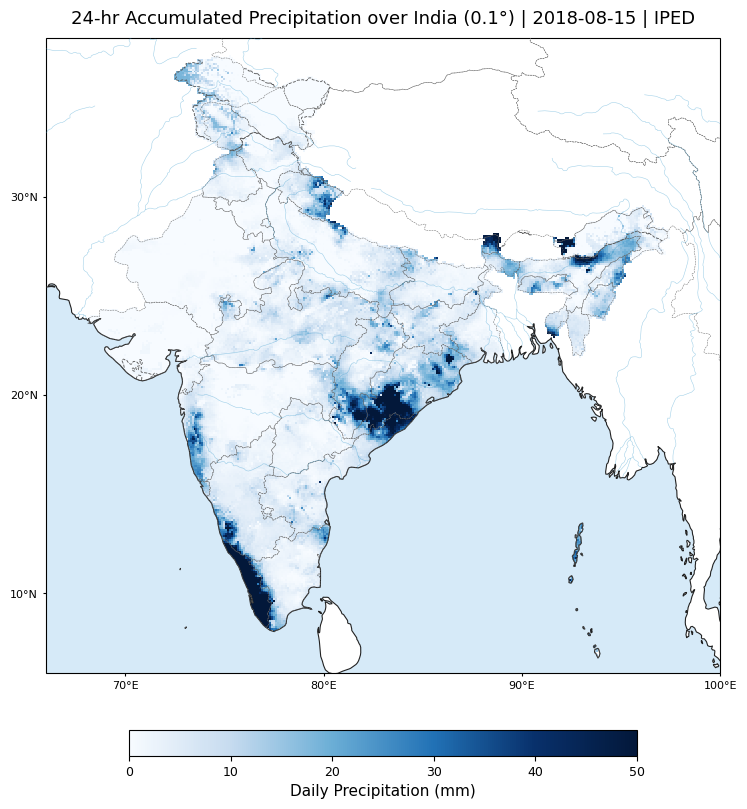

Done → iped_precip_2018.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# ── Load IPED dataset ─────────────────────────────────────────────
file = "/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_2018.nc"
ds = xr.open_dataset(file)

# ── Select Date ───────────────────────────────────────────────────
time_sel = "2018-08-15"
rain = ds["pcp"].sel(time=time_sel)

# ── Indian region bounds (SAME as ERA5) ───────────────────────────
lat_min, lat_max = 6.0, 38.0
lon_min, lon_max = 66.0, 100.0

# IMPORTANT: IPED lat is usually ascending → slice correctly
rain = rain.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

# ── Convert to numpy ──────────────────────────────────────────────
vals = rain.values
lats = rain.lat.values
lons = rain.lon.values

# ── SAME Colormap as ERA5 ─────────────────────────────────────────
colors_tp = ['#f7fbff', '#c6dbef', '#6baed6', '#2171b5', '#08306b', '#03183a']
cmap_tp   = mcolors.LinearSegmentedColormap.from_list('tp_blue', colors_tp, N=256)

vmin, vmax = 0, 50  # daily rainfall

# ── Plot (SAME STYLE) ─────────────────────────────────────────────
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

lons2d, lats2d = np.meshgrid(lons, lats)

ax.pcolormesh(
    lons2d, lats2d, vals,
    cmap=cmap_tp, vmin=vmin, vmax=50,
    transform=proj, shading='auto'
)

# ── SAME FEATURES (THIS ENSURES KASHMIR LOOKS SAME) ───────────────
ax.add_feature(cfeature.OCEAN,     facecolor='#d6eaf8', zorder=2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#222222', zorder=3)
ax.add_feature(cfeature.STATES,    linewidth=0.35, edgecolor='#666666',
               linestyle='--', zorder=3)

# SAME disputed boundaries logic
ne_disputed = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_disputed_areas',
    scale='10m',
    facecolor='none',
    edgecolor='#555555'
)
ax.add_feature(ne_disputed, linewidth=0.6, linestyle='--', zorder=10)

# Rivers
ax.add_feature(cfeature.RIVERS, linewidth=0.4,
               edgecolor='#3399cc', alpha=0.45, zorder=3)

# ── Extent ───────────────────────────────────────────────────────
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# ── SAME AXIS STYLE ──────────────────────────────────────────────
ax.set_xticks(np.arange(70, 101, 10), crs=proj)
ax.set_yticks(np.arange(10, 38, 10), crs=proj)

from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.tick_params(labelsize=8, length=2)

# ── Title ────────────────────────────────────────────────────────
ax.set_title(
    f'24-hr Accumulated Precipitation over India (0.1°) | {time_sel} | IPED',
    fontsize=13,
    pad=10
)

# ── Colorbar (SAME STYLE AS ERA5) ─────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap_tp, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

cbar = fig.colorbar(
    sm, ax=ax,
    orientation='horizontal',
    fraction=0.04,
    pad=0.06
)

cbar.set_label('Daily Precipitation (mm)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# ── Save ─────────────────────────────────────────────────────────
plt.savefig('iped_precip_2018.png', dpi=150,
            bbox_inches='tight', facecolor='white')

plt.show()
print("Done → iped_precip_2018.png")

In [21]:
import xarray as xr
import numpy as np

# ── Load ERA5 ─────────────────────────────────────────────
path = "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"
ds = xr.open_zarr(path, consolidated=True, storage_options={"token": "anon"})

# ── Year variable ─────────────────────────────────────────
yr = 2021

# ── Select time range dynamically ─────────────────────────
ds = ds.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))

# ── India region ──────────────────────────────────────────
lat_min, lat_max = 6, 38
lon_min, lon_max = 66, 100

era5 = ds["total_precipitation_24hr"].sel(
    latitude=slice(lat_max, lat_min),   # descending
    longitude=slice(lon_min, lon_max)
)

# ── Convert to mm ─────────────────────────────────────────
era5 = era5 * 1000.0

print(f"ERA5 shape ({yr}):", era5.shape)

ERA5 shape (2021): (1460, 129, 137)


In [22]:
# Load IPED
file = f"/kaggle/input/datasets/priyanshuss9913/rainfall-india/03_IPED_RES_0P10/IPED_Mean/IPED_mean_{yr}.nc"
ds_iped = xr.open_dataset(file)

iped = ds_iped["pcp"]

# Match India region
iped = iped.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

print(iped.shape)

(365, 304, 293)


In [23]:
# Coarsen IPED to ~1° (approx 10x since 0.1° → 1°)
iped_coarse = iped.coarsen(lat=10, lon=10, boundary='trim').mean()

# Align ERA5 to same time
era5 = era5.sel(time=iped_coarse.time)

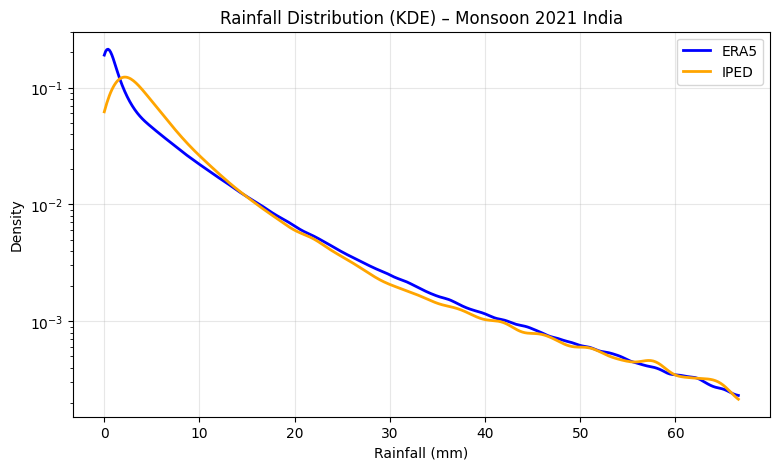

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, skew

# ── Select last 5 years (2018–2022) ─────────────────────────────
era5_5yr = era5.sel(time=slice(f"{yr}-06-01", f"{yr}-9-30"))
iped_5yr = iped_coarse.sel(time=slice(f"{yr}-06-01", f"{yr}-9-30"))

# ── Monsoon months (JJAS) ───────────────────────────────────────
era5_monsoon = era5_5yr.sel(time=era5_5yr['time.month'].isin([6,7,8,9]))
iped_monsoon = iped_5yr.sel(time=iped_5yr['time.month'].isin([6,7,8,9]))

# ── Flatten + clean ─────────────────────────────────────────────
era5_vals = era5_monsoon.values.flatten()
iped_vals = iped_monsoon.values.flatten()

era5_vals = era5_vals[~np.isnan(era5_vals)]
iped_vals = iped_vals[~np.isnan(iped_vals)]

# ── KDE computation ─────────────────────────────────────────────
x = np.linspace(0, np.percentile(np.concatenate([era5_vals, iped_vals]), 99.5), 500)

kde_era5 = gaussian_kde(era5_vals)
kde_iped = gaussian_kde(iped_vals)

# # ── Plot KDE ────────────────────────────────────────────────────
# plt.figure(figsize=(9,5))

# plt.plot(x, kde_era5(x), label="ERA5", linewidth=2)
# plt.plot(x, kde_iped(x), label="IPED", linewidth=2)

# # Log scale (important for rainfall)

# plt.xlabel("Rainfall (mm)")
# plt.ylabel("Density")
# plt.title("Rainfall Distribution (KDE) – Monsoon 2018 India)")

# plt.legend()
# plt.grid(alpha=0.3)

# plt.show()


plt.figure(figsize=(9,5))

# Compute KDE values
y_era5 = kde_era5(x)
y_iped = kde_iped(x)

# Plot lines
plt.plot(x, y_era5, color="blue", linewidth=2, label="ERA5")
plt.plot(x, y_iped, color="orange", linewidth=2, label="IPED")

# 🔥 Fill areas
# plt.fill_between(x, y_era5, color="blue", alpha=0.4)
# plt.fill_between(x, y_iped, color="orange", alpha=0.4)
plt.yscale("log")

plt.xlabel("Rainfall (mm)")
plt.ylabel("Density")
plt.title(f"Rainfall Distribution (KDE) – Monsoon {yr} India")

plt.legend()
plt.grid(alpha=0.3)
# ── Save ─────────────────────────────────────────────────────────
plt.savefig(f'dis_{yr}.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

In [25]:
from scipy.stats import entropy, wasserstein_distance
import numpy as np
def describe(data, name):
    print(f"\n{name} Statistics:")
    print(f"Mean       : {np.mean(data):.2f}")
    print(f"Std Dev    : {np.std(data):.2f}")
    print(f"Skewness   : {skew(data):.2f}")
    print(f"Median     : {np.median(data):.2f}")
    print(f"95th pct   : {np.percentile(data, 95):.2f}")
    print(f"99th pct   : {np.percentile(data, 99):.2f}")

describe(era5_vals, "ERA5")
describe(iped_vals, "IPED")


ERA5 Statistics:
Mean       : 6.58
Std Dev    : 11.10
Skewness   : 4.69
Median     : 2.58
95th pct   : 25.78
99th pct   : 52.94

IPED Statistics:
Mean       : 7.28
Std Dev    : 10.64
Skewness   : 4.93
Median     : 4.00
95th pct   : 24.55
99th pct   : 53.86


In [26]:
# ── Create common histogram (IMPORTANT for KL) ────────────────
bins = np.linspace(
    0,
    np.percentile(np.concatenate([era5_vals, iped_vals]), 99.5),
    100
)

hist_era5, _ = np.histogram(era5_vals, bins=bins, density=True)
hist_iped, _ = np.histogram(iped_vals, bins=bins, density=True)

# Add small epsilon to avoid log(0)
eps = 1e-10
hist_era5 = hist_era5 + eps
hist_iped = hist_iped + eps

# Normalize (important for KL)
hist_era5 /= hist_era5.sum()
hist_iped /= hist_iped.sum()

# ── KL Divergence ────────────────────────────────────────────
kl_div = entropy(hist_era5, hist_iped)

# ── Wasserstein Distance ─────────────────────────────────────
wd = wasserstein_distance(era5_vals, iped_vals)

print("\n📊 Distribution Distance Metrics:\n")
print(f"KL Divergence       : {kl_div:.4f}")
print(f"Wasserstein Distance: {wd:.4f}")


📊 Distribution Distance Metrics:

KL Divergence       : 0.2166
Wasserstein Distance: 0.9865
